# Minor Project 2: Student Performance and Attendance Analyzer

**Dataset:** Student Academic Performance.xlsx  
**Tools:** Python, Pandas, Matplotlib, Seaborn  

---

## Problem Statement

Educational institutions need to analyze student performance and attendance to identify patterns, weak areas, and overall outcomes. This project analyzes academic records to support data-driven decisions by examining marks distribution, subject-wise comparisons, and the relationship between attendance and academic performance.

---
## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print('Libraries imported successfully.')

Libraries imported successfully.


---
## Step 2: Load the Dataset

In [2]:
df = pd.read_excel('Student Academic Performance.xlsx')
print(f'Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns')
df.head()

Dataset loaded: 100 rows x 14 columns


,Student ID,Student Name,Attendance (%),Attendance Category,Mathematics,Science,English,Computer Science,Social Studies,Total Marks,Average Marks,Grade,Result,Class Rank
0,STU001,Lavanya Reddy,82.5,Medium,46.0,72.6,54.8,43.3,81.1,297.8,59.6,D,Pass,72
1,STU002,Aditi Nair,72.9,Medium,58.1,72.8,56.0,55.4,93.0,335.3,67.1,C,Pass,35
2,STU003,Lakshmi Mehta,84.7,Medium,62.8,84.2,79.1,68.0,46.9,341.0,68.2,C,Pass,26
3,STU004,Esha Reddy,97.8,High,59.8,87.6,81.0,72.5,80.3,381.2,76.2,B,Pass,6
4,STU005,Omkar Tiwari,71.5,Medium,61.5,43.3,63.6,57.2,54.2,279.8,56.0,D,Pass,91


---
## Step 3: Inspect Structure

In [3]:
print('Shape:', df.shape)
print('\nColumn Names:', df.columns.tolist())
print('\nData Types:')
print(df.dtypes)

Shape: (100, 14)

Column Names: ['Student ID', 'Student Name', 'Attendance (%)', 'Attendance Category', 'Mathematics', 'Science', 'English', 'Computer Science', 'Social Studies', 'Total Marks', 'Average Marks', 'Grade', 'Result', 'Class Rank']

Data Types:
Student ID              object
Student Name            object
Attendance (%)         float64
Attendance Category     object
Mathematics            float64
Science                float64
English                float64
Computer Science       float64
Social Studies         float64
Total Marks            float64
Average Marks          float64
Grade                   object
Result                  object
Class Rank               int64
dtype: object


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Student ID           100 non-null    object 
 1   Student Name         100 non-null    object 
 2   Attendance (%)       100 non-null    float64
 3   Attendance Category  100 non-null    object 
 4   Mathematics          100 non-null    float64
 5   Science              100 non-null    float64
 6   English              100 non-null    float64
 7   Computer Science     100 non-null    float64
 8   Social Studies       100 non-null    float64
 9   Total Marks          100 non-null    float64
 10  Average Marks        100 non-null    float64
 11  Grade                100 non-null    object 
 12  Result               100 non-null    object 
 13  Class Rank           100 non-null    int64  
dtypes: float64(8), int64(1), object(5)
memory usage: 11.1+ KB


---
## Step 4: Data Cleaning and Validation

In [5]:
# Check for missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found.')

Missing values per column:
No missing values found.


In [6]:
# Fill missing values if any (precautionary)
subject_cols = ['Mathematics', 'Science', 'English', 'Computer Science', 'Social Studies']
df[subject_cols] = df[subject_cols].fillna(df[subject_cols].mean())
df['Attendance (%)'] = df['Attendance (%)'].fillna(df['Attendance (%)'].median())

# Check for duplicate rows
print(f'Duplicate rows: {df.duplicated().sum()}')

# Validate marks are in 0-100 range
for col in subject_cols:
    out_of_range = df[(df[col] < 0) | (df[col] > 100)]
    if len(out_of_range) > 0:
        print(f'Warning: {len(out_of_range)} out-of-range values in {col}')
    
print('Data validation complete. Dataset is clean.')

Duplicate rows: 0
Data validation complete. Dataset is clean.


---
## Step 5: Summary Statistics

In [7]:
# Overall descriptive statistics
df[subject_cols + ['Attendance (%)', 'Average Marks']].describe().round(2)

,Mathematics,Science,English,Computer Science,Social Studies,Attendance (%),Average Marks
count,100.00,100.00,100.00,100.00,100.00,100.00,100.00
mean,64.86,65.18,66.13,63.55,62.79,73.42,64.50
std,14.32,16.64,13.20,15.56,13.85,13.57,6.93
min,34.10,11.40,39.80,33.50,21.30,35.70,42.80
25%,54.10,52.48,56.00,51.38,54.12,66.00,59.22
50%,65.25,65.65,65.55,63.15,63.40,73.10,65.35
75%,73.50,76.38,76.72,73.68,71.60,81.07,68.25
max,100.00,100.00,98.30,100.00,97.10,100.00,80.60


In [8]:
# Key performance indicators
pass_rate = (df['Result'] == 'Pass').mean() * 100
avg_attendance = df['Attendance (%)'].mean()
avg_marks = df['Average Marks'].mean()
top_subject = df[subject_cols].mean().idxmax()
weak_subject = df[subject_cols].mean().idxmin()

print(f'Pass Rate        : {pass_rate:.1f}%')
print(f'Average Attendance: {avg_attendance:.1f}%')
print(f'Average Marks    : {avg_marks:.1f} / 100')
print(f'Best Subject     : {top_subject} ({df[top_subject].mean():.1f})')
print(f'Weakest Subject  : {weak_subject} ({df[weak_subject].mean():.1f})')

Pass Rate        : 100.0%
Average Attendance: 73.4%
Average Marks    : 64.5 / 100
Best Subject     : English (66.1)
Weakest Subject  : Social Studies (62.8)


---
## Step 6: Grade and Result Distribution

In [9]:
print('Grade Distribution:')
print(df['Grade'].value_counts().sort_index())
print('\nResult Distribution:')
print(df['Result'].value_counts())

Grade Distribution:
Grade
A     1
B    18
C    52
D    27
F     2
Name: count, dtype: int64

Result Distribution:
Result
Pass    100
Name: count, dtype: int64


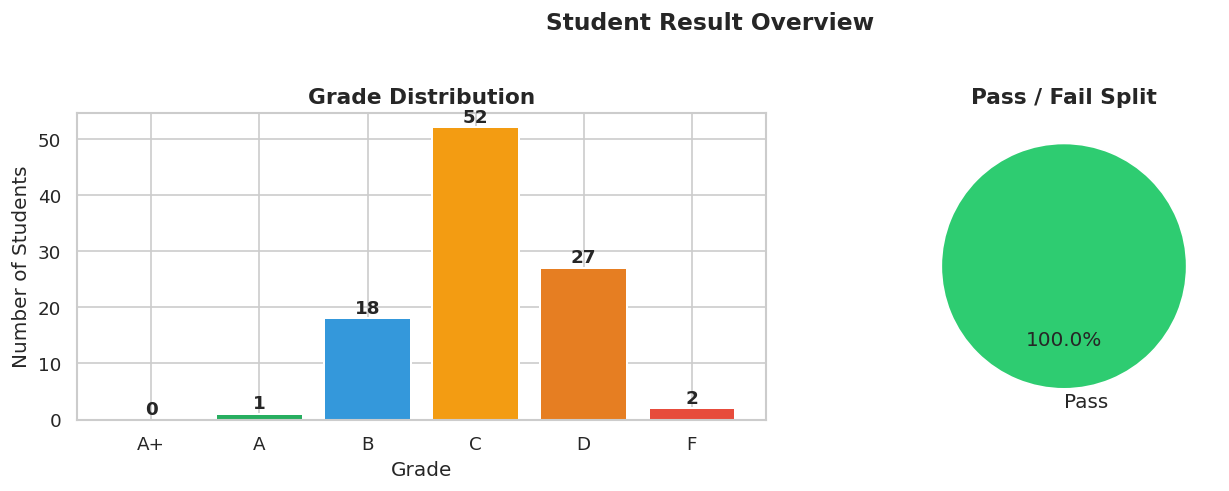

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Grade distribution
grade_order = ['A+', 'A', 'B', 'C', 'D', 'F']
grade_counts = df['Grade'].value_counts().reindex(grade_order, fill_value=0)
colors = ['#2ecc71', '#27ae60', '#3498db', '#f39c12', '#e67e22', '#e74c3c']
bars = axes[0].bar(grade_counts.index, grade_counts.values, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Grade Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Grade')
axes[0].set_ylabel('Number of Students')
for bar, val in zip(bars, grade_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, str(val),
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

# Pass/Fail pie
result_counts = df['Result'].value_counts()
axes[1].pie(result_counts.values, labels=result_counts.index,
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Pass / Fail Split', fontsize=13, fontweight='bold')

plt.suptitle('Student Result Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Step 7: Marks Distribution (Histogram)

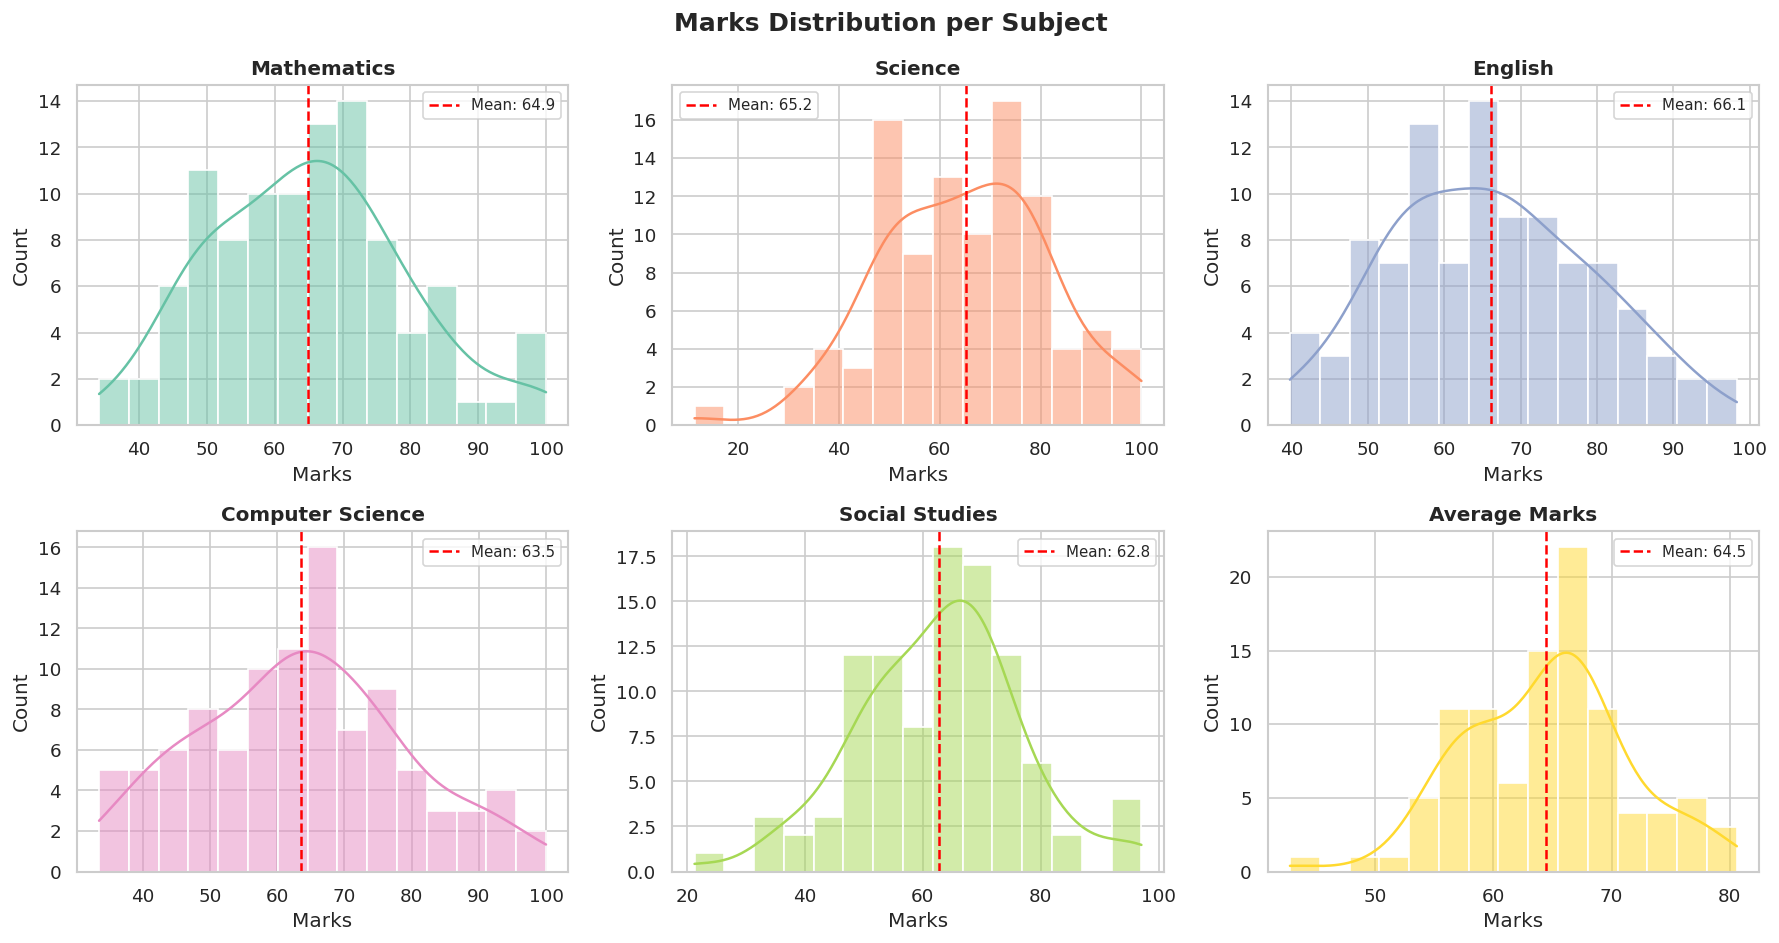

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

all_cols = subject_cols + ['Average Marks']
palette = sns.color_palette('Set2', len(all_cols))

for i, col in enumerate(all_cols):
    sns.histplot(df[col], bins=15, kde=True, ax=axes[i], color=palette[i], edgecolor='white')
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Marks')
    axes[i].set_ylabel('Count')
    mean_val = df[col].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    axes[i].legend(fontsize=9)

plt.suptitle('Marks Distribution per Subject', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 8: Subject-wise Performance (Box Plot)

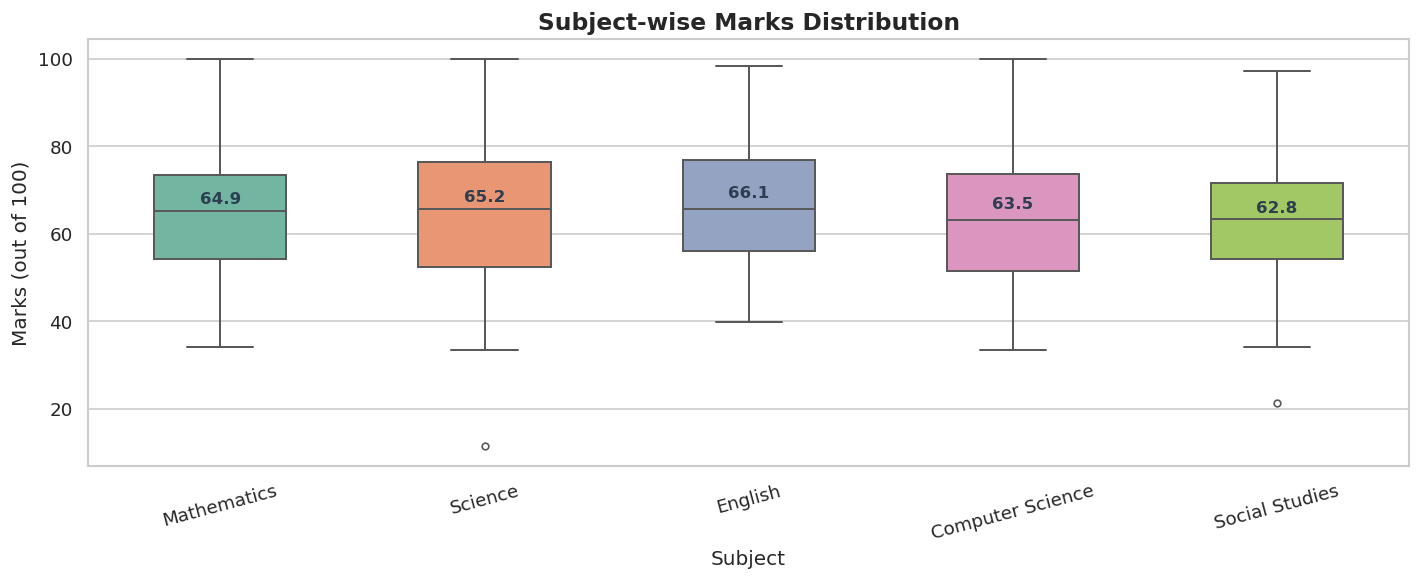

In [12]:
subject_long = df[subject_cols].melt(var_name='Subject', value_name='Marks')

plt.figure(figsize=(12, 5))
sns.boxplot(data=subject_long, x='Subject', y='Marks',
            palette='Set2', width=0.5, linewidth=1.2,
            flierprops=dict(marker='o', color='gray', markersize=4))
plt.title('Subject-wise Marks Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Subject', fontsize=12)
plt.ylabel('Marks (out of 100)', fontsize=12)
plt.xticks(rotation=15)

# Annotate means
means = subject_long.groupby('Subject')['Marks'].mean()
for i, subj in enumerate(subject_cols):
    plt.text(i, means[subj] + 1.5, f'{means[subj]:.1f}',
             ha='center', va='bottom', fontsize=10, color='#2c3e50', fontweight='bold')

plt.tight_layout()
plt.show()

---
## Step 9: Attendance vs Performance Analysis

In [13]:
# Group-wise average marks by attendance category
att_group = df.groupby('Attendance Category')['Average Marks'].mean().reindex(['Low', 'Medium', 'High'])
print('Average Marks by Attendance Category:')
print(att_group.round(2))

Average Marks by Attendance Category:
Attendance Category
Low       60.26
Medium    64.66
High      68.90
Name: Average Marks, dtype: float64


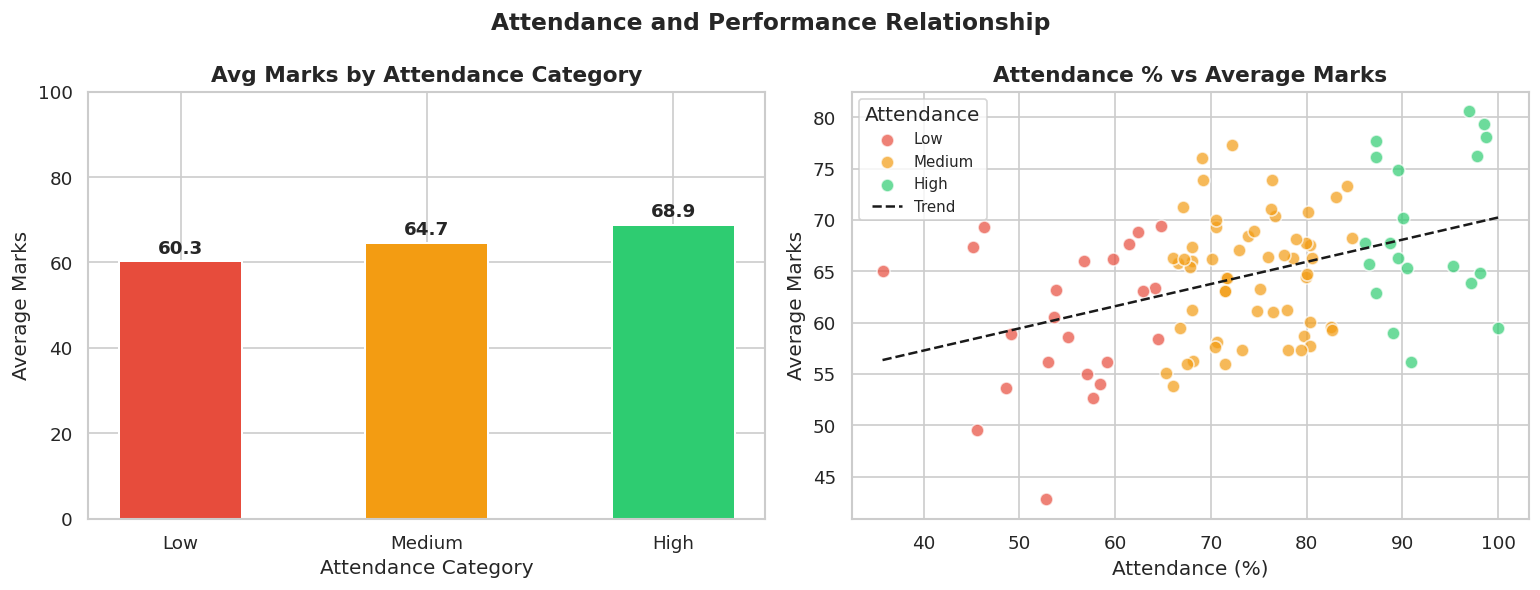

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar plot: attendance category vs average marks
cat_order = ['Low', 'Medium', 'High']
cat_colors = ['#e74c3c', '#f39c12', '#2ecc71']
att_avg = df.groupby('Attendance Category')['Average Marks'].mean().reindex(cat_order)
bars = axes[0].bar(att_avg.index, att_avg.values, color=cat_colors, edgecolor='white', linewidth=1.2, width=0.5)
axes[0].set_title('Avg Marks by Attendance Category', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Attendance Category')
axes[0].set_ylabel('Average Marks')
axes[0].set_ylim(0, 100)
for bar, val in zip(bars, att_avg.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Scatter: attendance % vs average marks
color_map = {'Low': '#e74c3c', 'Medium': '#f39c12', 'High': '#2ecc71'}
for cat in cat_order:
    subset = df[df['Attendance Category'] == cat]
    axes[1].scatter(subset['Attendance (%)'], subset['Average Marks'],
                    label=cat, color=color_map[cat], alpha=0.7, edgecolors='white', s=60)

# Trend line
z = np.polyfit(df['Attendance (%)'], df['Average Marks'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Attendance (%)'].min(), df['Attendance (%)'].max(), 100)
axes[1].plot(x_line, p(x_line), 'k--', linewidth=1.5, label='Trend')
axes[1].set_title('Attendance % vs Average Marks', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Attendance (%)')
axes[1].set_ylabel('Average Marks')
axes[1].legend(title='Attendance', fontsize=9)

plt.suptitle('Attendance and Performance Relationship', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 10: Subject-wise Average Marks (Bar Plot)

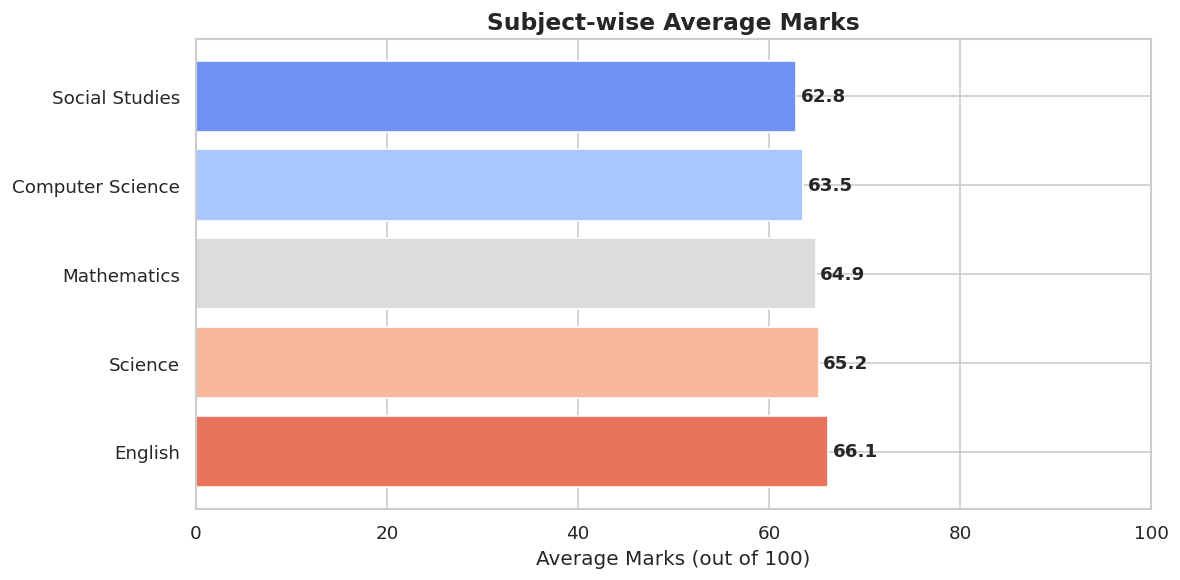

In [15]:
subject_means = df[subject_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
palette = sns.color_palette('coolwarm', len(subject_cols))
bars = plt.barh(subject_means.index, subject_means.values, color=palette[::-1], edgecolor='white', linewidth=1)
plt.xlabel('Average Marks (out of 100)', fontsize=12)
plt.title('Subject-wise Average Marks', fontsize=14, fontweight='bold')
plt.xlim(0, 100)
for bar, val in zip(bars, subject_means.values):
    plt.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}', va='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 11: Attendance Distribution

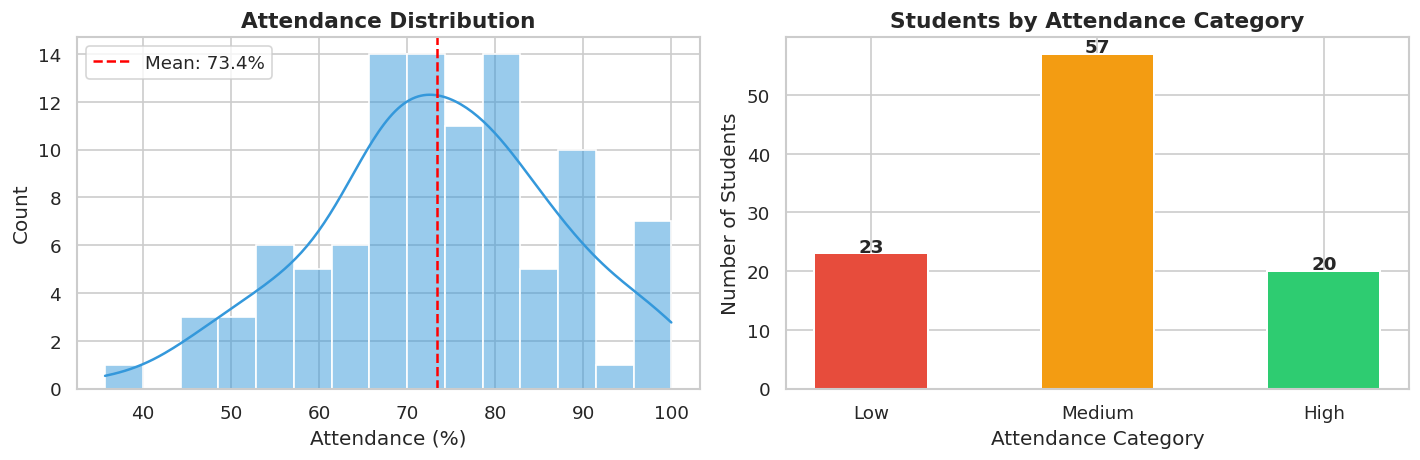

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of attendance
sns.histplot(df['Attendance (%)'], bins=15, kde=True, ax=axes[0], color='#3498db', edgecolor='white')
axes[0].axvline(df['Attendance (%)'].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f"Mean: {df['Attendance (%)'].mean():.1f}%")
axes[0].set_title('Attendance Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Attendance (%)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Count by category
att_count = df['Attendance Category'].value_counts().reindex(['Low', 'Medium', 'High'])
axes[1].bar(att_count.index, att_count.values,
            color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='white', linewidth=1.2, width=0.5)
axes[1].set_title('Students by Attendance Category', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Attendance Category')
axes[1].set_ylabel('Number of Students')
for i, (idx, val) in enumerate(att_count.items()):
    axes[1].text(i, val + 0.3, str(val), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

---
## Step 12: Correlation Heatmap

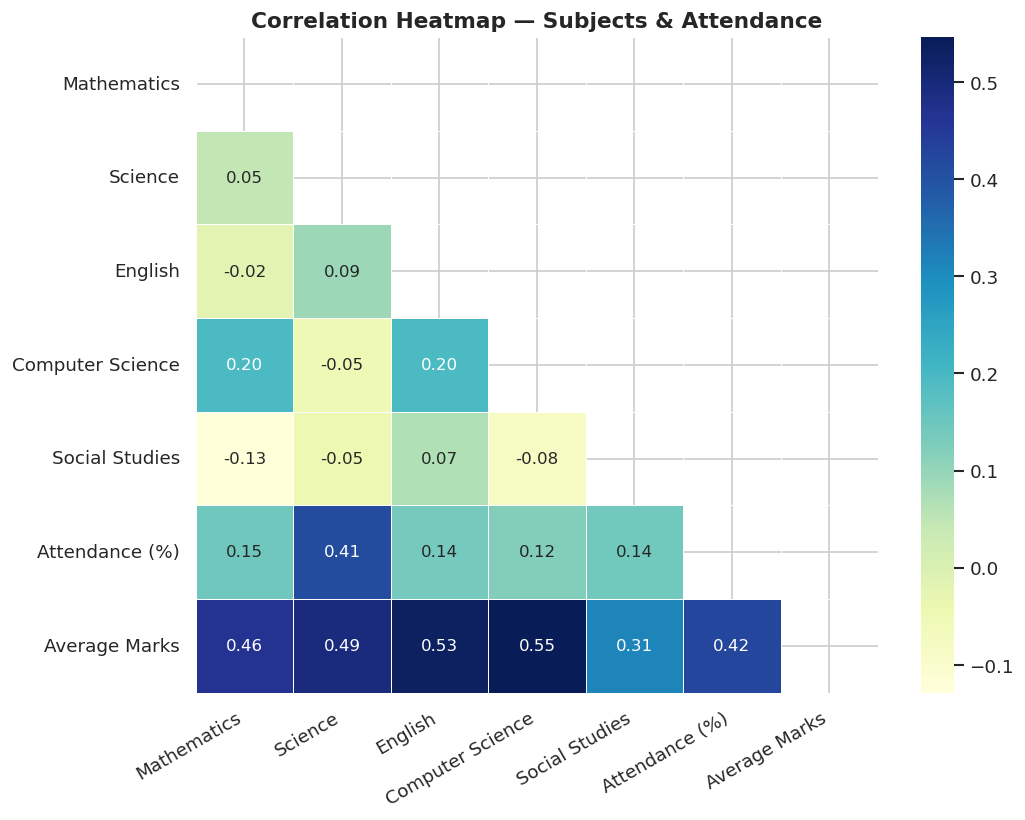

In [17]:
corr_cols = subject_cols + ['Attendance (%)', 'Average Marks']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='YlGnBu',
            mask=mask, linewidths=0.5, linecolor='white',
            annot_kws={'size': 10})
plt.title('Correlation Heatmap — Subjects & Attendance', fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

---
## Step 13: Top 10 Performers

In [18]:
top10 = df.nlargest(10, 'Average Marks')[['Student ID', 'Student Name', 'Average Marks', 'Grade', 'Attendance (%)']]
top10 = top10.reset_index(drop=True)
top10.index += 1
top10

,Student ID,Student Name,Average Marks,Grade,Attendance (%)
1,STU021,Deepika Singh,80.6,A,97.0
2,STU074,Omkar Reddy,79.4,B,98.5
3,STU007,Vivek Patel,78.1,B,98.7
4,STU035,Deepika Pillai,77.7,B,87.3
5,STU062,Uday Rao,77.3,B,72.2
6,STU004,Esha Reddy,76.2,B,97.8
7,STU065,Chetan Patel,76.1,B,87.2
8,STU095,Lakshmi Pandey,76.0,B,69.1
9,STU092,Aditi Reddy,74.9,B,89.5
10,STU052,Jiya Pandey,73.9,B,69.2


---
## Step 14: Key Findings and Conclusions

Based on the exploratory data analysis, the following insights were drawn:

1. **Attendance drives performance**: Students in the *High* attendance category consistently scored higher average marks than *Medium* or *Low* attendance students. The scatter plot confirms a clear positive trend between attendance % and average marks.

2. **Subject difficulty varies**: The bar chart shows unequal average marks across subjects. Subjects with lower averages indicate areas where students need additional support or resources.

3. **Marks are approximately normally distributed**: Histograms across all subjects show a roughly bell-shaped distribution with most students clustering around the mean, suggesting the assessment difficulty is well-calibrated.

4. **Box plots reveal outliers**: Some subjects have students performing significantly below the lower quartile — these students may benefit from targeted intervention.

5. **Pass rate**: The overall pass rate and grade distribution provide a snapshot of institutional performance and can guide curriculum decisions.

---
*Project by: [Your Name] | Submitted to: UNILOX Academy | Deadline: Monday EOD*